# Poisoned Mushroom Dataset

We are going to take a quick tour of machine learning by working on an example dataset. The mushroom dataset
categorizes mushrooms as 'poisonous' or 'edible' and collects several descriptive properties of each mushroom example.

In [51]:
import pandas as pd
import os

## Loading the dataset

In [52]:
# These lines would load the data locally
# data_root = "./"
# filename = "mushroom.csv"
# filepath = os.path.join(data_root, filename)

# We'll fetch it directly from the web
data_url = "https://aet-cs.github.io/white/2025/ML/data/mushroom.csv"
df = pd.read_csv(data_url)
df

,class,cap-shape,cap-surface,cap-color,ruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,e,x,f,n,f,n,f,w,n,b,...,y,w,p,NaN,n,o,p,w,v,NaN
1,p,NaN,y,g,t,NaN,f,c,b,k,...,s,n,c,p,w,n,e,NaN,y,g
2,e,b,y,n,t,n,f,c,NaN,n,...,s,p,NaN,p,w,o,p,b,y,w
3,e,x,g,g,t,n,f,w,b,n,...,s,p,NaN,p,w,n,n,NaN,NaN,d
4,e,NaN,f,NaN,t,n,a,w,n,n,...,k,NaN,w,p,w,NaN,l,w,v,d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25981,e,f,NaN,r,f,n,f,NaN,n,NaN,...,NaN,n,p,p,w,o,p,k,v,NaN
25982,e,f,s,e,f,NaN,f,c,n,y,...,y,w,p,p,w,NaN,p,r,y,d
25983,p,f,g,e,NaN,NaN,a,c,b,b,...,y,w,NaN,p,w,o,p,h,v,m
25984,e,x,g,g,t,n,f,w,b,h,...,f,NaN,NaN,p,w,t,e,NaN,s,NaN


`describe` gives a quick overview of each feature

In [53]:
df.describe()

,class,cap-shape,cap-surface,cap-color,ruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,25986,22513,22507,22527,22514,22536,22505,22587,22494,22418,...,22563,22413,22553,22489,22483,22497,22478,22493,22475,22502
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,14354,7674,7602,4810,12361,6986,17811,16092,13997,3679,...,10619,8580,8403,22489,15742,15713,8501,5085,8409,6573


All the features in this dataset are categorical, with between 2 and 12 categories. Except the curious `veil-type` which has only one value. Since `veil-type` has only one unique value, we'll drop it.

In [54]:
df = df.drop(columns="veil-type")

## Data Exploration

Show all the columns. Notice the target is the first column!

In [55]:
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'ruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type',
       'spore-print-color', 'population', 'habitat'],
      dtype='object')

Get the size of the dataframe. Shape returns (rows, cols)

In [56]:
df.shape

(25986, 22)

Let's peek at the target

In [57]:
df['class']

,class
0,e
1,p
2,e
3,e
4,e
...,...
25981,e
25982,e
25983,p
25984,e


This dataset has a LOT of "N/A" datapoints. One way to clean the data is to drop all affected rows

In [58]:
df.dropna().shape

(1327, 22)

But this *significantly* reduces our dataset. Let's instead use a data imputation strategy that fills the N/A with the *mode*

In [59]:
for c in df.columns:
    df = df.fillna({c: df[c].mode()[0]})

Pandas can do the same fill in one line. `df.mode()` returns a frame whose first row holds the most common value of every column, and `.iloc[0]` turns that row into the Series `fillna` wants. It produces exactly the same result as the loop above.

In [60]:
# Alternate version of the cell above
# df = df.fillna(df.mode().iloc[0])

Look at df again

In [61]:
df

,class,cap-shape,cap-surface,cap-color,ruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,e,x,f,n,f,n,f,w,n,b,...,s,y,w,p,n,o,p,w,v,d
1,p,x,y,g,t,n,f,c,b,k,...,f,s,n,c,w,n,e,w,y,g
2,e,b,y,n,t,n,f,c,b,n,...,s,s,p,w,w,o,p,b,y,w
3,e,x,g,g,t,n,f,w,b,n,...,s,s,p,w,w,n,n,w,v,d
4,e,x,f,n,t,n,a,w,n,n,...,s,k,w,w,w,o,l,w,v,d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25981,e,f,y,r,f,n,f,c,n,b,...,s,s,n,p,w,o,p,k,v,d
25982,e,f,s,e,f,n,f,c,n,y,...,s,y,w,p,w,o,p,r,y,d
25983,p,f,g,e,f,n,a,c,b,b,...,s,y,w,w,w,o,p,h,v,m
25984,e,x,g,g,t,n,f,w,b,h,...,k,f,w,w,w,t,e,w,s,d


Let's see what the classifications are and how balanced the dataset is. Highly imbalanced datasets require special techniques to ensure valid models.

In [62]:
df['class'].value_counts()

,count
class,
e,14354
p,11632


We'll introduce a new plotting library -- "seaborn", which has some advantages over matplotlib. Here we show how to quickly make a histogram from a dataframe. Seaborn works nicely with pandas dataframes.

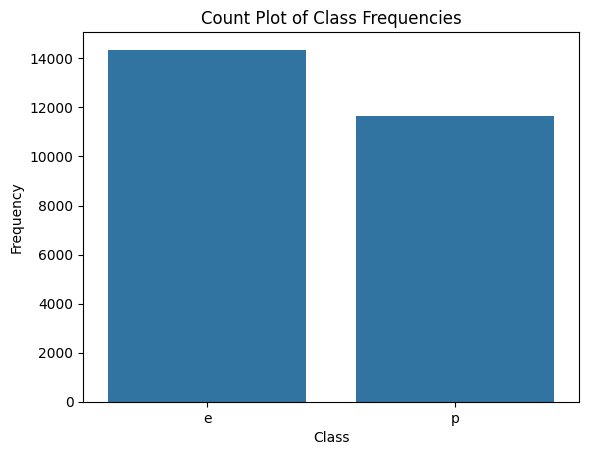

In [63]:
import seaborn as sns
from matplotlib import pyplot as plt

# Count plot
sns.countplot(df, x="class")
plt.title('Count Plot of Class Frequencies')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()


As another example let's plot the "cap color" feature.

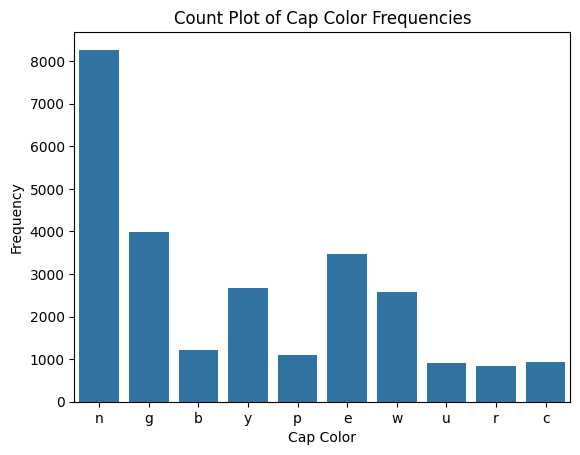

In [64]:
# Count plot
sns.countplot(df, x="cap-color")
plt.title('Count Plot of Cap Color Frequencies')
plt.xlabel('Cap Color')
plt.ylabel('Frequency')
plt.show()


I wonder how the color correlates to the outcome -- are some color more poisonous? We'll do some pandas work to make this summary for us. (Here's a nice overview of `groupby`: https://builtin.com/data-science/pandas-groupby)

In [65]:
# Count observations by color and toxicity
counts = df.groupby(['cap-color', 'class']).size().reset_index(name='count')

In [66]:
counts

,cap-color,class,count
0,b,e,660
1,b,p,551
2,c,e,526
3,c,p,413
4,e,e,1834
5,e,p,1627
6,g,e,2226
7,g,p,1765
8,n,e,4616
9,n,p,3653


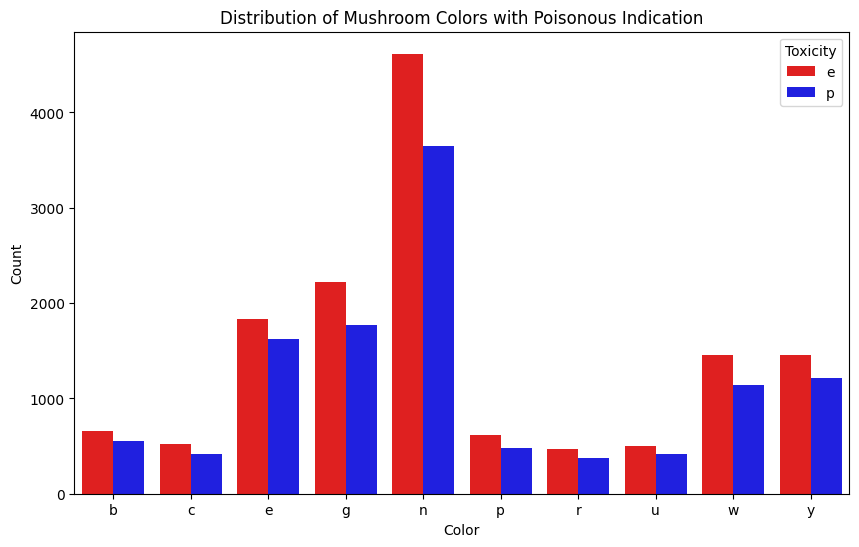

In [67]:
# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(counts, x="cap-color", y="count", hue="class",
            palette={"p": "blue", "e": "red"})

# Add plot title and labels
plt.title("Distribution of Mushroom Colors with Poisonous Indication")
plt.xlabel("Color")
plt.ylabel("Count")
plt.legend(title="Toxicity")

# Show the plot
plt.show()

Seaborn can build that same picture in one step, counting the rows for us instead of us counting them first with `groupby`. The `groupby` version is worth knowing because the counts table is useful on its own, but this is the short way.

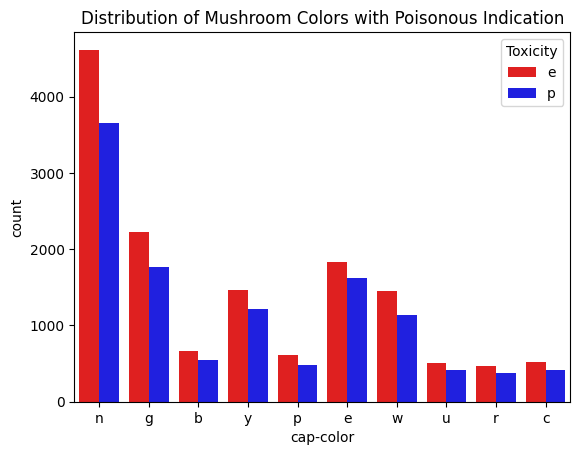

In [68]:
sns.countplot(df, x="cap-color", hue="class",
              palette={"p": "blue", "e": "red"})
plt.title("Distribution of Mushroom Colors with Poisonous Indication")
plt.legend(title="Toxicity")
plt.show()

In [69]:
df.describe()

,class,cap-shape,cap-surface,cap-color,ruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,25986,25986,25986,25986,25986,25986,25986,25986,25986,25986,...,25986,25986,25986,25986,25986,25986,25986,25986,25986,25986
unique,2,6,4,10,2,9,2,2,2,12,...,4,4,9,9,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,s,w,w,w,o,p,w,v,d
freq,14354,11147,11081,8269,15833,10436,21292,19491,17489,7247,...,14548,14042,12153,11836,19245,19202,12009,8578,11920,10057


In [70]:
# Count observations by odor and toxicity
counts = df.groupby(['odor', 'class']).size().reset_index(name='count')

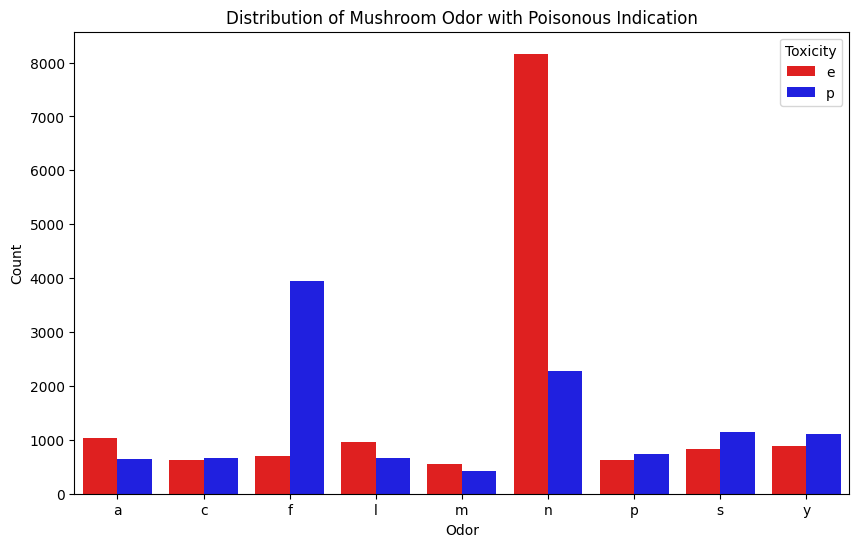

In [71]:
# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(counts, x="odor", y="count", hue="class",
            palette={"p": "blue", "e": "red"})

# Add plot title and labels
plt.title("Distribution of Mushroom Odor with Poisonous Indication")
plt.xlabel("Odor")
plt.ylabel("Count")
plt.legend(title="Toxicity")

# Show the plot
plt.show()

## Correlation matrix heat map

Let's get a quick visual representation of the relationshop between features in this dataset. We'll use a version of a Chi-Squared test on all pairs $(n,m)$ of features in the dataset, including the target. (Heat maps for continuous data are easy to plot -- because of the categories we have to do some extra work here. You can treat `cramers_v` as a black box for now.)

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Function to calculate Cramér's V
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table).statistic
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

categorical_columns = df.select_dtypes(include=['object', 'category']).columns
corr_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

for col1 in categorical_columns:
    for col2 in categorical_columns:
        corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Convert to numeric values for plotting
corr_matrix = corr_matrix.astype(float)
corr_matrix

,class,cap-shape,cap-surface,cap-color,ruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
class,0.999922,0.030397,0.043075,0.020084,0.089974,0.465191,0.001138,0.063779,0.122908,0.088500,...,0.129749,0.102529,0.050202,0.044377,0.005063,0.022175,0.092049,0.124672,0.063370,0.053764
cap-shape,0.030397,1.000000,0.011547,0.020761,0.014305,0.020779,0.008688,0.017270,0.017995,0.020523,...,0.011107,0.017404,0.018379,0.017432,0.017128,0.007926,0.012183,0.016205,0.018208,0.015867
cap-surface,0.043075,0.011547,1.000000,0.022589,0.008736,0.024878,0.015569,0.027291,0.020465,0.025335,...,0.012902,0.012060,0.022897,0.021619,0.012788,0.016706,0.014214,0.016301,0.022058,0.020441
cap-color,0.020084,0.020761,0.022589,1.000000,0.021542,0.022804,0.017171,0.023427,0.021974,0.024858,...,0.019545,0.016909,0.024867,0.020831,0.017487,0.015235,0.023721,0.019681,0.023478,0.022749
ruises,0.089974,0.014305,0.008736,0.021542,0.999919,0.043431,0.002767,0.015149,0.011158,0.041328,...,0.025761,0.021659,0.027672,0.031543,0.006508,0.011759,0.037341,0.034545,0.014283,0.026531
odor,0.465191,0.020779,0.024878,0.022804,0.043431,1.000000,0.017001,0.026458,0.046978,0.027601,...,0.027740,0.031568,0.025946,0.023086,0.015490,0.019458,0.030861,0.032236,0.026293,0.021654
gill-attachment,0.001138,0.008688,0.015569,0.017171,0.002767,0.017001,0.999870,0.004789,0.007753,0.023883,...,0.008627,0.011742,0.020285,0.021662,0.010471,0.004408,0.010966,0.010641,0.012992,0.012999
gill-spacing,0.063779,0.017270,0.027291,0.023427,0.015149,0.026458,0.004789,0.999897,0.011227,0.021896,...,0.011253,0.014541,0.022406,0.028543,0.008439,0.013913,0.013069,0.018936,0.027893,0.029246
gill-size,0.122908,0.017995,0.020465,0.021974,0.011158,0.046978,0.007753,0.011227,0.999913,0.031603,...,0.008155,0.009570,0.027692,0.030796,0.004786,0.008013,0.039065,0.041701,0.025668,0.023956
gill-color,0.088500,0.020523,0.025335,0.024858,0.041328,0.027601,0.023883,0.021896,0.031603,1.000000,...,0.030065,0.031451,0.023405,0.027307,0.019835,0.019987,0.033363,0.031731,0.029769,0.026966


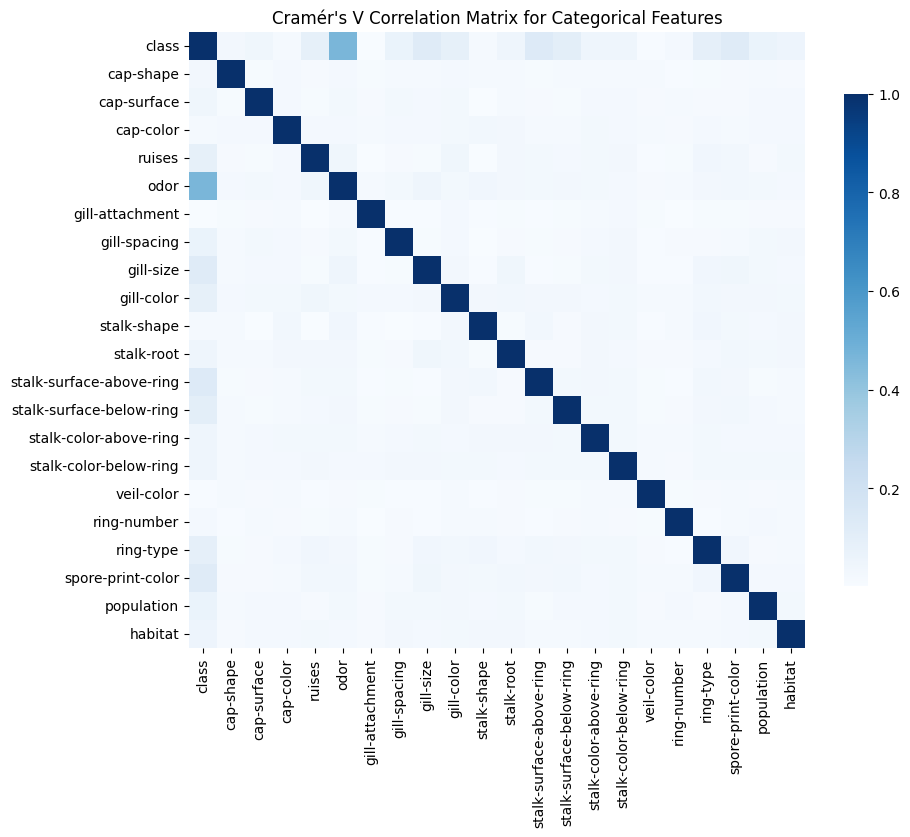

In [73]:
# Plotting the correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap='Blues', square=True, cbar_kws={"shrink": .8})
plt.title("Cramér's V Correlation Matrix for Categorical Features")
plt.show()

Which features seem to be important?

In [74]:
# Note that "class" appears here too, at 1.0 -- a feature is perfectly
# associated with itself.
corr_matrix.loc[corr_matrix["class"] > 0.1, "class"]

,class
class,0.999922
odor,0.465191
gill-size,0.122908
stalk-surface-above-ring,0.129749
stalk-surface-below-ring,0.102529
spore-print-color,0.124672


## Data Modeling

We're finally ready to do some data modeling using scikit-learn. In this cell we import some methods we'll use, reload the data frame (just to be safe), re-pre-process-it, and one-hot-encode all the categorical variables.

We reload the raw file here, so the missing values are back. We fill them the same way we did above, so that the models see the same data we explored. Later in this notebook we will undo this choice and see what it cost us.

In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv(data_url)

# drop the useless feature
df = df.drop(columns="veil-type")

# fill the missing values with the most common value in each column,
# exactly as we did during exploration
for c in df.columns:
    df = df.fillna({c: df[c].mode()[0]})

# drop the target from X -- and store it as y
X = df.drop(columns="class")
y = df['class']

# one-hot encode all columns at once
X = pd.get_dummies(X)

# one-hot encoding turned 21 columns into many more -- look at how many
print(X.shape)
X.head()

(25986, 116)


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,False,True,True,False,False,False,...,False,True,False,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,True,...,False,False,True,False,True,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,True
3,False,False,False,False,False,True,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
4,False,False,False,False,False,True,True,False,False,False,...,False,True,False,True,False,False,False,False,False,False


### Decision Tree Classifier

Our first model is a decision tree, which is one of the oldest algorithms for classifying observations. Before we create any models, we *always* create a train-test split so there is unseen testing data that wasn't available when the model was training.

In [76]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize the DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)

# Fit the model
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)
results = pd.DataFrame({"actual": y_test, "predicted": y_pred})
results.head(20)

,actual,predicted
15615,e,p
12738,e,e
17138,e,p
7183,e,p
13881,p,e
4351,e,p
23444,e,e
12986,p,e
25693,e,p
12716,p,p


There are many metrics for evaluating categorical models, and they are sometimes at odds. Accuracy is simplistic and obscures what could be more important -- are there more false positives or more false negatives? And which is more important? In a task to identify poisonous mushrooms, a false negative (labeling a 'p' as an 'e') is deadly. The "recall" on the positive class (in this case, 'p') below captures this value. This measures the percent of poisonous mushrooms you have correctly labeled as poisonous. Recall is also called sensitivity.

Recall is not everything, though. You can easily get perfect "poison" recall by labeling every mushroom as poisonous! Precision measures the fraction of mushrooms you label as poisonous which actually are.

The $F_1$-score is the harmonic mean of precision and recall, which strikes a balance between the two.

Scikit-learn has a built-in report that prints all of these, but it prints them twice, once from the point of view of each class, which is more than we need right now. Since a poisonous mushroom is what we are hunting for, we will treat **p as the positive class** for the whole notebook and build a small report of our own. Look first at sensitivity, but keep an eye on the other numbers.

In [77]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.632


A confusion matrix is a nice way to really show everything that a classifier is doing. The main diagonal are the numbers of correctly classified observations. The off-diagonals are errors. Unfortunately this simple version is unlabeled

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrix(y_test, y_pred)

array([[1880,  991],
       [ 923, 1404]])

With a bit more work we can get a label.

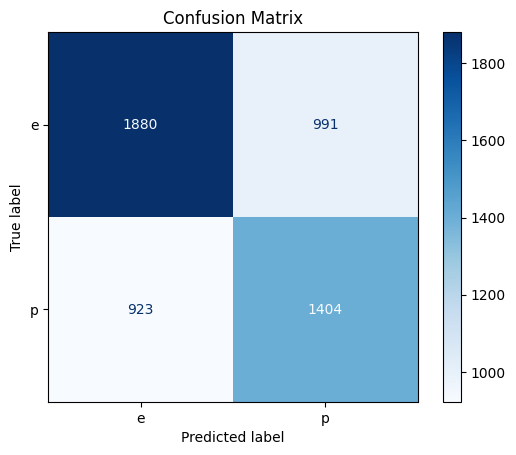

In [79]:
# scikit-learn will build and label the whole thing for us
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Every metric we care about can be read straight off that 2x2 table. Rather than computing them by hand each time, here is a small function that pulls the four counts out of the confusion matrix and turns them into the rates from our earlier vocabulary lesson.

The `labels=["e", "p"]` argument matters. It pins edible first and poisonous second, so that the four counts always come out in the order we expect. Without it we would be trusting alphabetical order to put the classes where we want them.

In [80]:
def poison_report(y_true, y_pred):
    """Report everything from one point of view: positive = poisonous."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=["e", "p"]).ravel()

    def safe_divide(a, b):
        return a / b if b else float("nan")

    print("Positive class = poisonous")
    print(f"  TP (poison, caught)       {tp:6d}")
    print(f"  FN (poison, MISSED)       {fn:6d}")
    print(f"  FP (edible, false alarm)  {fp:6d}")
    print(f"  TN (edible, cleared)      {tn:6d}")
    print()
    print(f"  Recall       {safe_divide(tp, tp + fn):.3f}   of the poisonous ones, how many did we catch?")
    print(f"  Precision    {safe_divide(tp, tp + fp):.3f}   when we claim poison, how often are we right?")
    print(f"  Specificity  {safe_divide(tn, tn + fp):.3f}   of the edible ones, how many did we say are safe?")
    print(f"  Accuracy     {safe_divide(tp + tn, tp + tn + fp + fn):.3f}   overall, how often are we right?")


poison_report(y_test, y_pred)

Positive class = poisonous
  TP (poison, caught)         1404
  FN (poison, MISSED)          923
  FP (edible, false alarm)     991
  TN (edible, cleared)        1880

  Recall       0.603   of the poisonous ones, how many did we catch?
  Precision    0.586   when we claim poison, how often are we right?
  Specificity  0.655   of the edible ones, how many did we say are safe?
  Accuracy     0.632   overall, how often are we right?


### Testing more methods

First I'll define a helper method that takes any dataset and a classifier "clf" and
* fits the model to the training data
* applies the model to the test data
* prints our poison report for the test data
* hands back the numbers we want to collect

Notice the TODO inside it. Accuracy is the only number it currently returns, and accuracy
is not obviously the thing we should care about here. Decide which metric matters most for
this problem, add it, and be ready to defend the choice.

In [81]:
from sklearn.metrics import recall_score, precision_score, f1_score


def classifier_tryout(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)

    # Make predictions
    y_pred = clf.predict(X_test)

    # Our own view of the results, positive = poisonous
    poison_report(y_test, y_pred)

    # TODO: accuracy is not the only thing we care about on this problem.
    # Add one more metric below that you think matters more, then uncomment
    # the sort in the comparison section so the table ranks by your metric.
    # Some options, all of which need pos_label="p" so that "positive"
    # means poisonous and not whatever sorts last:
    recall = recall_score(y_test, y_pred, pos_label="p")
    precision = precision_score(y_test, y_pred, pos_label="p")
    f1 = f1_score(y_test, y_pred, pos_label="p")
    return {
        "model": type(clf).__name__,
        "accuracy": accuracy_score(y_test, y_pred),
        # "my_metric": ...,
    }


# We'll append each model's score here as we go
scores = []

In what follows, we run several very different models and compare their performance. We won't go into much detail about the models. But note how the scikit-learn API makes dealing with each of the models very similar

### Random Forest

In [82]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42)
scores.append(classifier_tryout(clf, X_train, y_train, X_test, y_test))

Positive class = poisonous
  TP (poison, caught)         1471
  FN (poison, MISSED)          856
  FP (edible, false alarm)     539
  TN (edible, cleared)        2332

  Recall       0.632   of the poisonous ones, how many did we catch?
  Precision    0.732   when we claim poison, how often are we right?
  Specificity  0.812   of the edible ones, how many did we say are safe?
  Accuracy     0.732   overall, how often are we right?


### Support Vector Machines

In [83]:
from sklearn.svm import SVC

# Initialize the SVC
clf = SVC(random_state=42, kernel='rbf')
scores.append(classifier_tryout(clf, X_train, y_train, X_test, y_test))

Positive class = poisonous
  TP (poison, caught)         1453
  FN (poison, MISSED)          874
  FP (edible, false alarm)     514
  TN (edible, cleared)        2357

  Recall       0.624   of the poisonous ones, how many did we catch?
  Precision    0.739   when we claim poison, how often are we right?
  Specificity  0.821   of the edible ones, how many did we say are safe?
  Accuracy     0.733   overall, how often are we right?


### Logistic Regression

In [84]:
from sklearn.linear_model import LogisticRegression

# Initialize the LogisticRegression
clf = LogisticRegression(random_state=42)
scores.append(classifier_tryout(clf, X_train, y_train, X_test, y_test))

Positive class = poisonous
  TP (poison, caught)         1495
  FN (poison, MISSED)          832
  FP (edible, false alarm)     558
  TN (edible, cleared)        2313

  Recall       0.642   of the poisonous ones, how many did we catch?
  Precision    0.728   when we claim poison, how often are we right?
  Specificity  0.806   of the edible ones, how many did we say are safe?
  Accuracy     0.733   overall, how often are we right?


### k-Nearest Neighbors

In [85]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNeighborsClassifier
clf = KNeighborsClassifier(weights='uniform')
scores.append(classifier_tryout(clf, X_train, y_train, X_test, y_test))

Positive class = poisonous
  TP (poison, caught)         1290
  FN (poison, MISSED)         1037
  FP (edible, false alarm)     727
  TN (edible, cleared)        2144

  Recall       0.554   of the poisonous ones, how many did we catch?
  Precision    0.640   when we claim poison, how often are we right?
  Specificity  0.747   of the edible ones, how many did we say are safe?
  Accuracy     0.661   overall, how often are we right?


### GradientBoost

In [86]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the GradientBoostingClassifier
clf = GradientBoostingClassifier(random_state=42)
scores.append(classifier_tryout(clf, X_train, y_train, X_test, y_test))

Positive class = poisonous
  TP (poison, caught)         1485
  FN (poison, MISSED)          842
  FP (edible, false alarm)     559
  TN (edible, cleared)        2312

  Recall       0.638   of the poisonous ones, how many did we catch?
  Precision    0.727   when we claim poison, how often are we right?
  Specificity  0.805   of the edible ones, how many did we say are safe?
  Accuracy     0.730   overall, how often are we right?


### Neural Network

In [87]:
from sklearn.neural_network import MLPClassifier

# Initialize the MLPClassifier
clf = MLPClassifier(random_state=42, hidden_layer_sizes=(1000,10,), learning_rate='adaptive')
scores.append(classifier_tryout(clf, X_train, y_train, X_test, y_test))

Positive class = poisonous
  TP (poison, caught)         1451
  FN (poison, MISSED)          876
  FP (edible, false alarm)     836
  TN (edible, cleared)        2035

  Recall       0.624   of the poisonous ones, how many did we catch?
  Precision    0.634   when we claim poison, how often are we right?
  Specificity  0.709   of the edible ones, how many did we say are safe?
  Accuracy     0.671   overall, how often are we right?


## Comparing the models

Now that every model has run, let's put the results side by side. The lone decision tree from earlier, which we ran before defining the helper, is not in this table. Look carefully at the spread. What does it tell you that these very different algorithms land where they do?

Once you have added your own metric to the helper, uncomment the second line and see whether the ranking changes. If it does, which model would you actually want to use in the woods? If it does not, why not?

In [88]:
summary = pd.DataFrame(scores).set_index("model")
# summary = summary.sort_values("my_metric", ascending=False)
summary

,accuracy
model,
RandomForestClassifier,0.731628
SVC,0.732974
LogisticRegression,0.732589
KNeighborsClassifier,0.660639
GradientBoostingClassifier,0.730473
MLPClassifier,0.670643


## What did imputation cost us?

Every model above was trained on data where we quietly replaced each missing value with the most common value in its column. That was a decision, not a fact about the data, and decisions can be tested. Here we undo it.

If we one-hot encode the columns while the missing values are still `NaN`, pandas does not create a column for them. A mushroom with a missing odor gets a zero in all nine odor columns, while every other mushroom gets exactly one 1. So the models can still tell that something is missing. It shows up as an absence rather than as a guess.

In [89]:
# Rebuild X and y WITHOUT filling in the missing values
df_raw = pd.read_csv(data_url).drop(columns="veil-type")

X_raw = pd.get_dummies(df_raw.drop(columns="class"))
y_raw = df_raw["class"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# Look at a mushroom whose odor was missing: all nine odor columns are zero
odor_columns = [c for c in X_raw.columns if c.startswith("odor_")]
X_raw.loc[df_raw["odor"].isna(), odor_columns].head()

,odor_a,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y
1,False,False,False,False,False,False,False,False,False
11,False,False,False,False,False,False,False,False,False
12,False,False,False,False,False,False,False,False,False
17,False,False,False,False,False,False,False,False,False
24,False,False,False,False,False,False,False,False,False


Now run the same models on the unimputed data. Nothing else changes: same split, same random states, same helper. Only the missing values are handled differently.

This cell trains six models and will take a few minutes.

In [90]:
models = {
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "SVC": SVC(random_state=42, kernel="rbf"),
    "LogisticRegression": LogisticRegression(random_state=42),
    "KNeighborsClassifier": KNeighborsClassifier(weights="uniform"),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "MLPClassifier": MLPClassifier(
        random_state=42, hidden_layer_sizes=(1000, 10), learning_rate="adaptive"
    ),
}

scores_no_impute = []
for name, clf in models.items():
    print("=" * 60)
    print(name)
    scores_no_impute.append(
        classifier_tryout(clf, X_train_raw, y_train_raw, X_test_raw, y_test_raw)
    )

DecisionTreeClassifier
Positive class = poisonous
  TP (poison, caught)         1478
  FN (poison, MISSED)          849
  FP (edible, false alarm)     895
  TN (edible, cleared)        1976

  Recall       0.635   of the poisonous ones, how many did we catch?
  Precision    0.623   when we claim poison, how often are we right?
  Specificity  0.688   of the edible ones, how many did we say are safe?
  Accuracy     0.664   overall, how often are we right?
RandomForestClassifier
Positive class = poisonous
  TP (poison, caught)         1556
  FN (poison, MISSED)          771
  FP (edible, false alarm)     572
  TN (edible, cleared)        2299

  Recall       0.669   of the poisonous ones, how many did we catch?
  Precision    0.731   when we claim poison, how often are we right?
  Specificity  0.801   of the edible ones, how many did we say are safe?
  Accuracy     0.742   overall, how often are we right?
SVC
Positive class = poisonous
  TP (poison, caught)         1602
  FN (poison, MISS

Line the two runs up against each other. The `change` column is the unimputed score minus the imputed one, so a positive number means that filling in the missing values made things worse.

The decision tree row is missing its imputed score, because we ran that first tree before we started collecting results. Scroll back up and compare it by hand. It moved the most of any model here.

In [91]:
comparison = pd.DataFrame(scores_no_impute).set_index("model").join(
    summary, lsuffix="_raw", rsuffix="_imputed", how="outer"
)
comparison["change"] = comparison["accuracy_raw"] - comparison["accuracy_imputed"]
comparison

,accuracy_raw,accuracy_imputed,change
model,,,
DecisionTreeClassifier,0.664486,NaN,NaN
GradientBoostingClassifier,0.742978,0.730473,0.012505
KNeighborsClassifier,0.673913,0.660639,0.013274
LogisticRegression,0.743555,0.732589,0.010966
MLPClassifier,0.693344,0.670643,0.022701
RandomForestClassifier,0.741631,0.731628,0.010004
SVC,0.741439,0.732974,0.008465


Some questions to answer before you move on.

1. Which way did the scores move, and was it the same for every model?
2. Mode filling writes the most common value into about one in eight of the entries in every column. How often is that guess wrong, and what does the model do with a wrong value that it cannot tell apart from a real one?
3. The missing values in this file were knocked out at random, with no connection to whether the mushroom is poisonous. So the fact that a value is missing tells you nothing about toxicity. Why would the unimputed version still do better?
4. Try a third strategy: `pd.get_dummies(..., dummy_na=True)` makes the missingness an explicit column instead of an all-zero row. Predict what will happen before you run it.
5. Under what circumstances would mode filling be the right choice?

## Conclusion

This notebook gave a quick overview of the full data analysis workflow on a real world dataset. Data ingesting and cleaning; exploratory data analysis; modeling. There is much we can do next by trying to optimize models, but that is beyond the scope of this notebook. Also, we only looked at categorical data here -- continuous/quantitative data is a bit different but not much (linear regression is the first stop with continuous data.)

Which model above do you think is the best? Which one would you start with to try to get even better results?

As an application, find your own dataset and try to mirror the process we took here. Not all the steps in this notebook will apply directly to whatever dataset you find, but see what you can come up with and how well you can model the target in your data!